# Блок заданий 05: классические методы без учителя

## Вспомогательный код

*(Можно не смотреть, но надо запустить)*

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats

In [2]:
ok = set()  # это служебная структура, чтобы Вам было проще смотреть все ли задания выполнены
all_tasks = (
    {'1.0', '1.1', '2.1', '2.2'}
)

Код из прошлого занятия:

In [3]:
from sklearn.base import BaseEstimator, TransformerMixin, ClusterMixin
from numbers import Real, Integral

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, accuracy_score
from sklearn.neighbors import KDTree

# на случай, если версия sklearn отличается очень существенно используем такой хак:
try:
    from sklearn.base import _fit_context
    from sklearn.utils._param_validation import StrOptions, Interval
except:
    _fit_context = lambda **kwargs: lambda fn: fn
    StrOptions = lambda _: None

try:
    from sklearn.utils import check_X_y
    from sklearn.utils import check_random_state
except:
    check_X_y = lambda X, y: None
    check_random_state = lambda rs: np.random.RandomState(rs)


## Задания

### 1. Вспомогательные функции



#### 1.0. Функция подсчёта расстояний между вектором и множеством векторов


**Задача:** реализуйте функцию, принимающую на вход вектор $q \in \mathbb{R}^{d}$ и матрицу $K^{M \times d}$, и возвращающую вектор расстояний $r$ размерности $M$, такой что:

$$
r_{j} = \lVert q - K_j \rVert
$$

*Обратите внимание, расстояние в формуле Евклидово, и не возводится в квадрат.*

- **Использовать циклы и сторонние функции запрещено, разрешены только операции NumPy**.
- Для вычисления нормы можно использовать `np.linalg.norm`, либо реализовать норму самостоятельно.

Здесь генерируются искусственные данные для обучения:

In [4]:
q = np.arange(23)
K = 42 * 23 - np.arange(42 * 23).reshape((42, 23))

Реализация модели:

In [5]:
def row_distances(q: np.ndarray, K: np.ndarray) -> np.ndarray:
    """Pairwise distances between `q` and `K`.

    Args:
        q: Query vector of shape (n_features).
        K: Key matrix of shape (n_keys, n_features).

    Returns:
        Distance array of shape (n_keys).

    """
    assert q.shape[0] == K.shape[1], \
        'Number of features should be the same for q and K'

    res = np.linalg.norm(K-q, axis=1)
    return res
    

In [ ]:
# ваш код для проверки функции, если требуется

Находим расстояния для заданных матриц:

In [6]:
res_1_0 = row_distances(q, K)
res_1_0.shape

(42,)

Проверки, что задание выполнено верно:

In [7]:
assert res_1_0.shape == (42,), 'Размерность должна быть `(K.shape[0])`'
for i in range(K.shape[0]):
    assert res_1_0[i] == np.linalg.norm(q - K[i]), 'В результате должны быть правильные расстояния'

ok.add('1.0')

#### 1.1. Функция подсчёта расстояний


**Задача:** реализуйте функцию, принимающую на вход две матрицы: $Q \in \mathbb{R}^{N \times d}$ и $K^{M \times d}$, и возвращающую матрицу расстояний $D$ размерности $N \times M$, такую что:

$$
D_{i,j} = \lVert Q_i - K_j \rVert
$$

*Обратите внимание, расстояние в формуле Евклидово, и не возводится в квадрат.*

- **Использовать циклы и сторонние функции запрещено, разрешены только операции NumPy**.
- Для вычисления нормы можно использовать `np.linalg.norm`, либо реализовать норму самостоятельно.

Здесь генерируются искусственные данные для обучения:

In [8]:
Q = np.arange(17 * 23).reshape((17, 23))
K = 42 * 23 - np.arange(42 * 23).reshape((42, 23))

Реализация модели:

In [9]:
def pairwise_distances(Q: np.ndarray, K: np.ndarray) -> np.ndarray:
    """Pairwise distances between `Q` and `K`.

    Args:
        Q: Query matrix of shape (n_queries, n_features).
        K: Key matrix of shape (n_keys, n_features).

    Returns:
        Distance array of shape (n_queries, n_keys).

    """
    assert Q.shape[1] == K.shape[1], \
        'Number of features should be the same for Q and K'

    res1 = Q[:, np.newaxis, :] - K[np.newaxis, :, :]
    return np.linalg.norm(res1, axis=2)
    

In [ ]:
# ваш код для проверки функции, если требуется

Находим расстояния для заданных матриц:

In [10]:
res_1_1 = pairwise_distances(Q, K)
res_1_1.shape

(17, 42)

Проверки, что задание выполнено верно:

In [11]:
assert res_1_1.shape == (17, 42), 'Размерности должны быть `(Q.shape[0], K.shape[0])`'
assert res_1_1[0, 0] == np.linalg.norm(Q[0] - K[0]), 'В результате должны быть правильные расстояния'
assert res_1_1[10, 0] == np.linalg.norm(Q[10] - K[0]), 'В результате должны быть правильные расстояния'
assert res_1_1[10, 10] == np.linalg.norm(Q[10] - K[10]), 'В результате должны быть правильные расстояния'
assert res_1_1[0, 10] == np.linalg.norm(Q[0] - K[10]), 'В результате должны быть правильные расстояния'

ok.add('1.1')

### 2. Кластеризация

#### 2.1. K-Means кластеризация

**Задача:** реализуйте классическую версию K-Means кластеризации.

- **Обязательно использовать Вашу функцию `pairwise_distances`**.
- **Готовую реализацию из библиотеки scikit-learn использовать нельзя**.
- Циклы по итерациям и по кластерам разрешены.

Здесь генерируются искусственные данные для обучения:

In [12]:
all_X, true_clusters = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=123)
X_train, X_test, tc_train, tc_test = train_test_split(
    all_X, true_clusters, test_size=0.5, random_state=12345
)

**Ваша реализация K-Means:**

In [14]:
class MyKMeans(ClusterMixin, BaseEstimator):
    _parameter_constraints: dict = {
        "n_clusters": [Interval(Integral, 1, None, closed='left')],
        "max_iter": [Interval(Integral, 1, None, closed='left')],
    }
    def __init__(self, n_clusters=3, max_iter=500, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state

    @_fit_context(prefer_skip_nested_validation=True)
    def fit(self, X, y=None):
        rng = check_random_state(self.random_state)  # генератор псевдослучайных чисел
        X = np.asarray(X)
        n_samples = X.shape[0]
        idx = rng.choice(n_samples, size=self.n_clusters, replace=False)
        self.cluster_centers_ = X[idx].copy()

        for _ in range(self.max_iter):
            D = pairwise_distances(X, self.cluster_centers_)
            labels = np.argmin(D, axis=1)
            new_centers = np.empty_like(self.cluster_centers_)
            for k in range(self.n_clusters):
                mask = labels == k
                if np.any(mask):
                    new_centers[k] = X[mask].mean(axis=0)
                else:
                    new_centers[k] = X[rng.randint(n_samples)]
            if np.allclose(new_centers, self.cluster_centers_):
                break
            self.cluster_centers_ = new_centers

        return self

    def predict(self, X):
        # метод должен вернуть номер кластера, в который попал каждый вектор-строка из `X`
        D = pairwise_distances(np.asarray(X), self.cluster_centers_)
        return np.argmin(D, axis=1)


Создаём модель, затем обучаем:

In [15]:
kmeans = MyKMeans(n_clusters=3, random_state=1)
kmeans.fit(X_train)

,n_clusters,3
,max_iter,500
,random_state,1


In [ ]:
# ваш код для проверки модели, если требуется

Text(0.5, 1.0, 'Тестовые примеры с предсказанными кластерами')

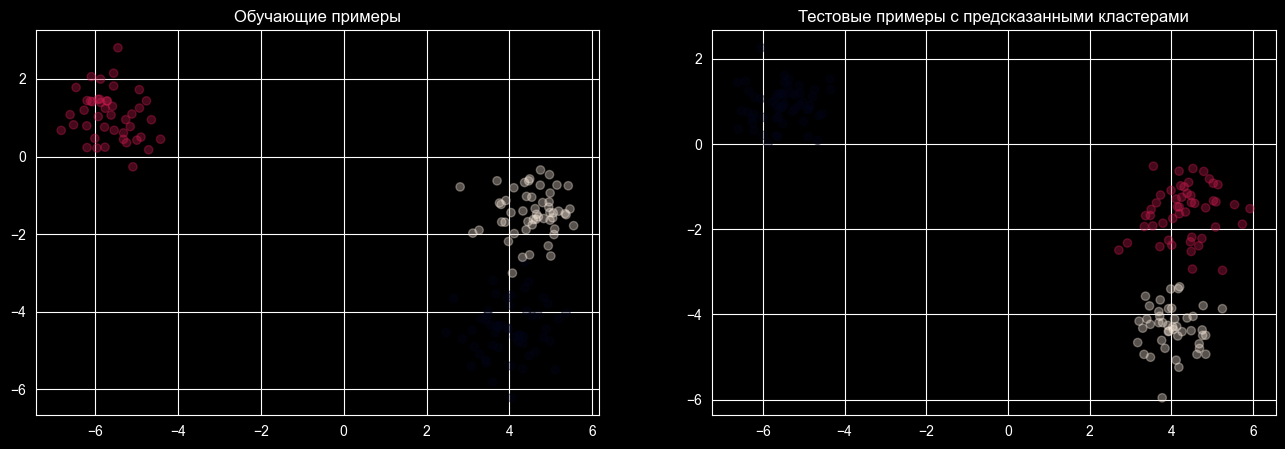

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].scatter(X_train[:, 0], X_train[:, 1], c=tc_train, alpha=0.35)
ax[0].set_title('Обучающие примеры')

ax[1].scatter(X_test[:, 0], X_test[:, 1], c=kmeans.predict(X_test), alpha=0.35)
ax[1].set_title('Тестовые примеры с предсказанными кластерами')

Метрики (мы генерировали данные сразу с метками эталонных кластеров, поэтому можем измерить точность
кластеризации; в жизни так часто не сделать), больше – лучше:

In [17]:
predictions = kmeans.predict(X_test)

for name, fn in {'ARS': adjusted_rand_score, 'NMI': normalized_mutual_info_score}.items():
    print(name, fn(tc_test, predictions))

ARS 0.9628477105213289
NMI 0.9493762056630858


Проверки, что задание выполнено верно:

In [18]:
assert isinstance(kmeans, MyKMeans), 'Модель должна быть нужного класса'
predictions = kmeans.predict(X_test)
assert predictions.shape[0] == X_test.shape[0], 'Модель должна возвращать верное число предсказаний'
assert normalized_mutual_info_score(tc_test, predictions) > 0.9, 'Кластеризация должна быть корректной'

ok.add('2.1')

#### 2.2. Жизненная задача

**Задача:** есть набор данных о транспортировочных пунктах с их признаками в Евклидовом пространстве (например, координаты).
Каждые два транспортировочных пункта обмениваются посылками, только, если находятся близко друг к другу. Транспортировочные пункты могут передавать посылку от одного к другому по цепочке промежуточных транспортировочных пунктов.

**Требуется** построить модель, принимающую на вход данные о двух транспортировочных пунктах, *A* и *B* (возможно, новых), и возвращающую **1**, если из одного можно доставить посылку в другой, и **0**, если нельзя.

- *Для решения можно использовать любые методы из библиотеки scikit-learn.*
- *Используйте данные без разметки и информацию о том, как принимается решение.*

Загружаем обучающие и тестовые данные ([https://disk.yandex.ru/d/hsZ6HA0E_jwNDA](https://disk.yandex.ru/d/hsZ6HA0E_jwNDA)):

In [19]:
data_2_2 = np.load('2.2_all.npz')
all_X = data_2_2['all_X']
X_a_train = data_2_2['X_a_train']
X_b_train = data_2_2['X_b_train']
y_train = data_2_2['y_train']
X_a_test = data_2_2['X_a_test']
X_b_test = data_2_2['X_b_test']
y_test = data_2_2['y_test']

**Ваше решение:**

In [22]:
from collections import deque
from sklearn.neighbors import radius_neighbors_graph


class Solution:
    def pair(self, a, b, r, G, tree):
        a = np.asarray(a, dtype=float)
        b = np.asarray(b, dtype=float)
        G = G.tocsr()
        na = set(tree.query_radius(a.reshape(1, -1), r)[0])
        nb = set(tree.query_radius(b.reshape(1, -1), r)[0])
        if np.linalg.norm(a - b) <= r:
            return True
        if na & nb:
            return True
        visited = np.zeros(G.shape[0], dtype=bool)
        q = deque()
        for i in na:
            visited[i] = True
            q.append(i)
        while q:
            i = q.popleft()
            if i in nb:
                return True
            for j in G[i].indices:
                if not visited[j]:
                    visited[j] = True
                    q.append(j)
        return False

    def fit(self, all_X, X_a, X_b, y):
        """Fit the model.

        Args:
            all_X: Available transport points, without labeling.
            X_a: Transport points A of shape (n_samples, n_features).
            X_b: Transport points B of shape (n_samples, n_features).
            y: Training label for each pair of points, of shape (n_samples).

        """
        self.all_X_ = np.asarray(all_X, dtype=float)
        self.tree_ = KDTree(self.all_X_)
        h = float(np.max(pairwise_distances(self.all_X_, self.all_X_)))
        if h == 0:
            h = 1.0
        y = np.asarray(y)
        y0 = np.flatnonzero(y == 0)
        y1 = np.flatnonzero(y == 1)
        c = 0.0
        best_r = None
        mid = h / 2
        for _ in range(60):
            mid = (c + h) / 2
            G = radius_neighbors_graph(self.all_X_, mid, mode='connectivity')
            too_large = False
            for i in y0:
                if self.pair(X_a[i], X_b[i], mid, G, self.tree_):
                    too_large = True
                    break
            if too_large:
                h = mid
                continue
            too_small = False
            for i in y1:
                if not self.pair(X_a[i], X_b[i], mid, G, self.tree_):
                    too_small = True
                    break
            if too_small:
                c = mid
            else:
                best_r = mid
                c = mid
        self.r_ = best_r if best_r is not None else mid
        return self

    def predict(self, X_a, X_b):
        """
        Args:
            X_a: Transport points A of shape (n_samples, n_features).
            X_b: Transport points B of shape (n_samples, n_features).

        Returns:
            For each pair of points A, B return 1 if A can transfer a package to B, and 0 otherwise.
            Result shape (n_samples).
        """
        assert X_a.shape == X_b.shape
        # надо рассмотреть каждую пару точек A, B в том смысле, что
        # требуется определить можно ли доставить посылку из X_a[0] в X_b[0], из X_a[1] в X_b[1],
        # и т.д., из X_a[i] в X_b[i] для каждого i от 0 до n_samples - 1

        X_a = np.asarray(X_a, dtype=float)
        X_b = np.asarray(X_b, dtype=float)
        G = radius_neighbors_graph(self.all_X_, self.r_, mode='connectivity')
        n = X_a.shape[0]
        out = np.empty(n, dtype=np.int64)
        for i in range(n):
            out[i] = int(self.pair(X_a[i], X_b[i], self.r_, G, self.tree_))
        return out


Создаём модель, затем обучаем:

In [23]:
solution = Solution()
solution.fit(all_X, X_a_train, X_b_train, y_train)

In [37]:
# ваш код для проверки модели, если требуется

Метрики:

In [24]:
print(
    'Accuracy on train',
    accuracy_score(
        y_train,
        solution.predict(X_a_train, X_b_train)
    )
)
print(
    'Accuracy on test',
    accuracy_score(
        y_test,
        solution.predict(X_a_test, X_b_test)
    )
)

Accuracy on train 1.0
Accuracy on test 1.0


Проверки, что задание выполнено верно:

In [25]:
assert isinstance(solution, Solution), 'Модель должна быть нужного класса'
predictions = solution.predict(X_a_test, X_b_test)
assert accuracy_score(y_test, predictions) > 0.99, 'Задача должна быть решена верно'

ok.add('2.2')

## Итоги

In [26]:
print(f'Выполнены задания: {ok}')
print(f'Осталось: {all_tasks - ok}')
print(f'Выполнено: {len(ok)}. Не выполнено: {len(all_tasks - ok)}')

Выполнены задания: {'1.1', '2.2', '2.1', '1.0'}
Осталось: set()
Выполнено: 4. Не выполнено: 0
